# 01 · Racionals: densitat i nombres que falten

[Obre aquest quadern a Google Colab](https://colab.research.google.com/github/mlacasa/1BATXILLERAT/blob/main/Q_conjunt_dens.ipynb)

**Matemàtiques · 1r de batxillerat**  
**Autoria: Dr. Lacasa-Cazcarra · Any 2026**

**Objectiu.** Distingir la densitat de ℚ de la completesa de ℝ i construir aproximacions exactes.

**Abans de començar:** fraccions, desigualtats i potències  
**Temps orientatiu:** 1–2 sessions. Hi ha activitats bàsiques i ampliacions opcionals.

**Funcionament.** Executa les cel·les en ordre, des del començament. Primer fes una predicció,
després experimenta i escriu una justificació. Els controls són opcionals: també pots
modificar els arguments de les funcions i executar-les. Les figures representen mostres
finites; les propietats infinites necessiten una demostració.

**Procedència.** Reelaboració de Q_conjunt_dens.ipynb del repositori original.


In [1]:
import math
from fractions import Fraction
from decimal import Decimal, localcontext
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True,
                     "font.size": 11, "figure.dpi": 100})

def explora(funcio, **rangs):
    """Controls opcionals: la mateixa funció també es pot cridar directament."""
    # Conservem un exemple estàtic per als lectors sense controls interactius.
    funcio()
    try:
        import ipywidgets as widgets
    except ImportError:
        print("Sense controls: executem els paràmetres per defecte. Pots canviar-los a la crida.")
        return None
    panell = widgets.interactive(funcio, **rangs)
    display(panell)
    return panell


## Ruta guiada per a 1r de batxillerat

**Pregunta de partida:** Si trobem deu decimals d'un nombre, ja sabem si és racional?

**Al final ho has de poder explicar:** Trobar intervals racionals cada vegada més estrets i explicar per què això no converteix √2 en racional.

La primera lectura combina l'exemple resolt amb el **laboratori animat** i les preguntes
que l'acompanyen. Els apartats marcats com a ampliació formal aprofundeixen en el rigor;
no cal entendre tot el codi per interpretar la matemàtica.

Dedica 2 minuts a una predicció escrita, 8–10 minuts a experimentar i pausar,
i 5 minuts a justificar una conclusió amb càlculs. Després resol el repte amb dades noves.
L'animació té controls de reproducció, pausa i selecció de fotograma.
Si el visor no mostra HTML interactiu, el fotograma estàtic i la funció
`fotograma_laboratori(...)` permeten fer la mateixa activitat pas a pas després d'executar el codi.


## 1. Predicció: podem esgotar els racionals d'un interval?
Si $p<q$ són racionals, el punt mig $m=(p+q)/2$ també és racional i satisfà $p<m<q$.
Repetir aquesta construcció dona infinits racionals entre $p$ i $q$.
Aquesta és la **densitat** de l'ordre de ℚ. No afirma que tots els punts de la recta siguin racionals.

Prediu els cinc primers resultats si comencem amb $[0,1]$ i conservem la meitat dreta.


In [2]:
def punts_mitjans(p="0", q="1", passos=10):
    p, q = Fraction(p), Fraction(q)
    if p >= q or not isinstance(passos, int) or passos < 0:
        raise ValueError("Cal p < q i un nombre enter no negatiu de passos.")
    resultat = []
    for _ in range(passos):
        p = (p + q) / 2
        resultat.append(p)
    return resultat

punts = punts_mitjans()
for i, valor in enumerate(punts, 1):
    print(f"a_{i} = {valor}; distància a 1 = {1 - valor}")


a_1 = 1/2; distància a 1 = 1/2
a_2 = 3/4; distància a 1 = 1/4
a_3 = 7/8; distància a 1 = 1/8
a_4 = 15/16; distància a 1 = 1/16
a_5 = 31/32; distància a 1 = 1/32
a_6 = 63/64; distància a 1 = 1/64
a_7 = 127/128; distància a 1 = 1/128
a_8 = 255/256; distància a 1 = 1/256
a_9 = 511/512; distància a 1 = 1/512
a_10 = 1023/1024; distància a 1 = 1/1024


**Justificació.** Per inducció, $a_n=1-2^{-n}$ per a $n\ge1$. Per tant $a_n<1$ sempre,
encara que la distància a 1 pugui ser tan petita com vulguem. Aquí el límit sí que és racional.

Canvia els extrems per `"2/7"` i `"5/9"`. Escriu una fórmula general per a $a_n$.
Fes servir cadenes o `Fraction(2, 7)`: `Fraction(0.1)` parteix d'un decimal binari ja arrodonit.


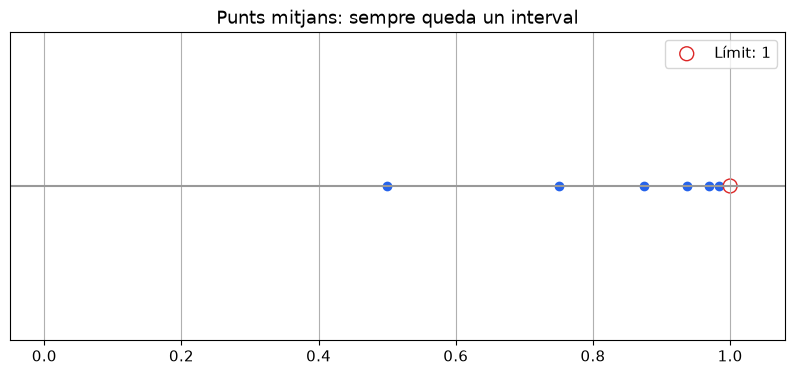

interactive(children=(IntSlider(value=6, description='passos', max=15, min=1), Output()), _dom_classes=('widge…

In [3]:
def dibuixa_racionals(passos=6):
    punts = punts_mitjans(passos=passos)
    fig, ax = plt.subplots()
    ax.axhline(0, color="0.6")
    ax.scatter([float(p) for p in punts], np.zeros(len(punts)), color="#2563eb")
    ax.scatter([1], [0], facecolors="none", edgecolors="#dc2626", s=100, label="Límit: 1")
    ax.set(xlim=(-.05, 1.08), ylim=(-.1, .1), yticks=[], title="Punts mitjans: sempre queda un interval")
    ax.legend(); plt.show()
panell = explora(dibuixa_racionals, passos=(1, 15, 1))


## 2. Busquem un nombre amb quadrat igual a 2
A l'interval $[1,2]$, comparem $m^2$ amb 2. Si $m^2<2$, conservem $[m,b]$;
si $m^2>2$, conservem $[a,m]$. **No necessitem conèixer el valor de l'arrel.**


In [4]:
def intervals_arrel2(passos=12):
    """Extrems racionals exactes. No calcula sqrt(2)."""
    if not isinstance(passos, int) or passos < 0:
        raise ValueError("El nombre de passos ha de ser un enter no negatiu.")
    a, b = Fraction(1), Fraction(2)
    intervals = [(a, b)]
    for _ in range(passos):
        m = (a + b) / 2
        if m * m < 2:
            a = m
        else:
            b = m
        intervals.append((a, b))
    return intervals


a = 181/128; b = 363/256; amplada exacta = 1/256
Comprovació exacta: a² < 2 < b²: True


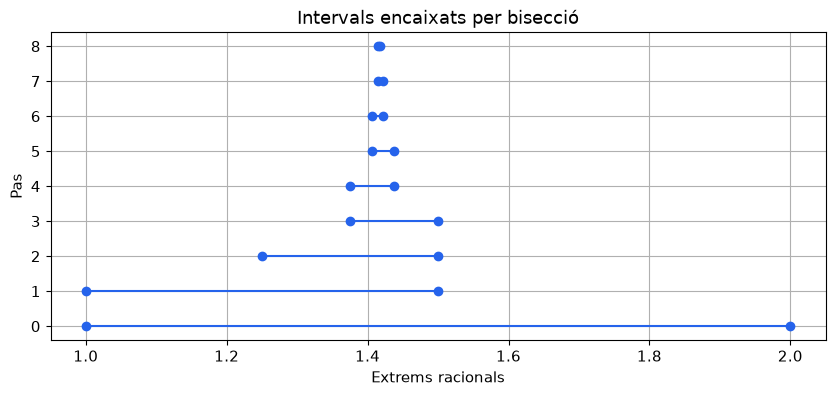

interactive(children=(IntSlider(value=8, description='passos', max=16), Output()), _dom_classes=('widget-inter…

In [5]:
def laboratori_biseccio(passos=8):
    intervals = intervals_arrel2(passos)
    a, b = intervals[-1]
    print(f"a = {a}; b = {b}; amplada exacta = {b-a}")
    print(f"Comprovació exacta: a² < 2 < b²: {a*a < 2 < b*b}")
    fig, ax = plt.subplots()
    for k, (a, b) in enumerate(intervals):
        ax.plot([float(a), float(b)], [k, k], "o-", color="#2563eb")
    ax.set(xlabel="Extrems racionals", ylabel="Pas", title="Intervals encaixats per bisecció")
    plt.show()
panell = explora(laboratori_biseccio, passos=(0, 16, 1))


## Laboratori animat · observa, atura i explica


### Un quadrat de superfície 2: quina longitud té el costat?

Un quadrat de costat 1 té àrea 1; un de costat 2 té àrea 4. Busquem un costat entre 1 i 2
amb àrea 2. No premem la tecla √: **provem, comparem i conservem mitja cerca**.

| Pas | Interval abans de provar | Punt mig m | m² | Decisió |
|---|---|---|---|---|
| 1 | [1, 2] | 3/2 | 9/4 > 2 | conservar [1, 3/2] |
| 2 | [1, 3/2] | 5/4 | 25/16 < 2 | conservar [5/4, 3/2] |
| 3 | [5/4, 3/2] | 11/8 | 121/64 < 2 | conservar [11/8, 3/2] |

La comparació $m^2<2$ o $m^2>2$ és exacta amb fraccions. El dibuix només en representa
les posicions aproximades. **Blau:** interval abans de decidir. **Verd:** meitat conservada.
El gràfic dret amplia l'interval actual; comprova les marques de l'eix perquè l'escala canvia.

**Prediu.** Quina serà l'amplada després de 5 passos? Completa primer la tercera fila a mà.
**Durant l'animació.** Pausa al pas 2 i explica per què descartem la meitat esquerra.


In [6]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def fotograma_laboratori(pas):
    """Mostra un estat quiet per poder llegir, dibuixar i prendre apunts."""
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.7), dpi=90)
    dibuixa_laboratori(pas, axes)
    fig.suptitle(titol_laboratori, fontsize=14, weight="bold")
    fig.tight_layout(rect=(0, 0, 1, .92))
    plt.show()

def anima_laboratori():
    """Animació HTML amb pausa i desplaçament manual; no necessita FFmpeg."""
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.7), dpi=80)
    def actualitza(pas):
        for ax in axes:
            ax.clear()
        dibuixa_laboratori(pas, axes)
        fig.suptitle(titol_laboratori, fontsize=14, weight="bold")
        fig.tight_layout(rect=(0, 0, 1, .92))
    animacio = FuncAnimation(fig, actualitza, frames=fotogrames_laboratori,
                             interval=700, repeat=False, cache_frame_data=False)
    try:
        contingut = animacio.to_jshtml(fps=1.5, default_mode="once")
    finally:
        plt.close(fig)
    return HTML(contingut)


In [7]:
titol_laboratori = "Buscar √2 sense conèixer-ne els decimals"
fotogrames_laboratori = list(range(10))

def estat_biseccio(pas):
    a, b = intervals_arrel2(pas)[-1]
    m = (a+b)/2
    nou = (m, b) if m*m < 2 else (a, m)
    return a, b, m, nou

def dibuixa_laboratori(pas, axes):
    a, b, m, (c, d) = estat_biseccio(pas)
    ax, bx = axes
    for k, (u, v) in enumerate(intervals_arrel2(pas+1)):
        ax.plot([float(u), float(v)], [k, k], "o-", color="#2563eb", lw=3)
    ax.set(xlim=(.95, 2.05), ylim=(-.7, 10.7), xlabel="Longitud del costat",
           ylabel="Nombre de decisions", title="Escala fixa: l'interval es va estrenyent")
    bx.plot([float(a), float(b)], [1, 1], "o-", lw=6, color="#2563eb", label="Abans")
    bx.plot([float(c), float(d)], [0, 0], "o-", lw=6, color="#047857", label="Després")
    bx.scatter([float(m)], [1], s=65, color="#ea580c", zorder=5)
    marge = float(b-a)*.18
    bx.set(xlim=(float(a)-marge, float(b)+marge), ylim=(-.6, 1.8),
           yticks=[0, 1], yticklabels=["Conservem", "Provem"], xlabel="Longitud (escala ampliada)",
           title=f"Pas {pas+1}: m = {m}\nm² {'<' if m*m < 2 else '>'} 2; amplada nova = {d-c}")
    bx.ticklabel_format(axis="x", style="plain", useOffset=False)
    bx.tick_params(axis="x", labelrotation=20)
    bx.legend(loc="upper right", fontsize=8)


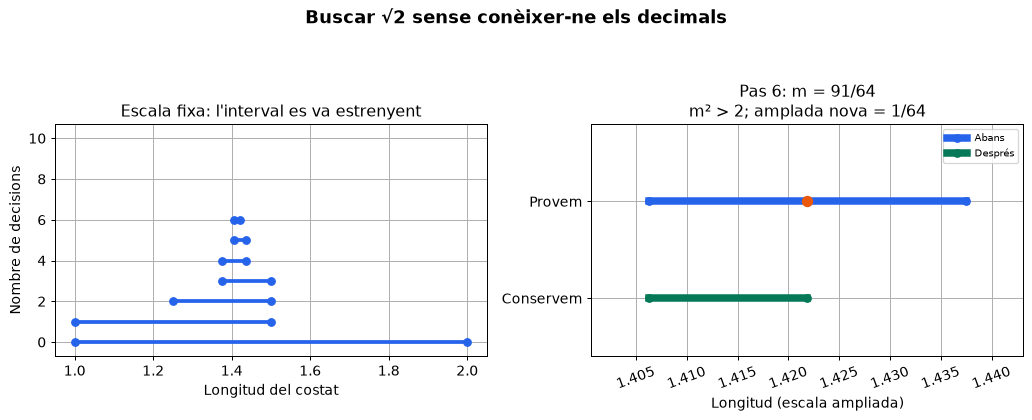

In [8]:
# Fotograma visible també quan no es reprodueix l'animació.
fotograma_laboratori(fotogrames_laboratori[len(fotogrames_laboratori)//2])


**Ara reprodueix l'animació.** Fes servir la pausa i el control de fotograma per contrastar la teva predicció. Els valors numèrics dels títols formen part de l'explicació.


In [9]:
display(anima_laboratori())


### Compara abans de concloure

Compara la primera i la sisena decisió. A l'esquerra, l'escala és fixa; a la dreta s'amplia cada interval. Calcula la proporció entre les amplades: no la dedueixis de la llargada del segment ampliat.

Tria dos estats amb els controls i prem **Compara els estats**. Llegeix les escales: algunes ampliacions del laboratori canvien els límits dels eixos. Justifica la comparació amb els nombres dels títols.


In [10]:
parella_comparacio = (0, 5)
etiquetes_comparacio = [f"Decisió {k+1}" for k in fotogrames_laboratori]
preguntes_taller = [{'enunciat': "Després de 4 biseccions d'un interval d'amplada 1, quina amplada queda?", 'opcions': ['1/4', '1/16', '0'], 'correcta': 1, 'retorn': ['Cada pas divideix per 2: són quatre divisions, no una divisió per 4.', 'Correcte: (1/2)⁴ = 1/16. La longitud encara és positiva.', 'Cap nombre finit de biseccions dona amplada zero en aquest procés exacte.']}, {'enunciat': "Si m² és menor que 2 i l'interval és positiu, quina meitat conservem?", 'opcions': ['[a,m]', 'Qualsevol de les dues', '[m,b]'], 'correcta': 2, 'retorn': ['Si m² < 2, el costat buscat és més gran que m.', 'La decisió depèn de la comparació; una meitat perdria el valor buscat.', "Correcte: en nombres positius, elevar al quadrat conserva l'ordre."]}, {'enunciat': 'Tots els punts mitjans són racionals. Què podem concloure sobre el límit?', 'opcions': ['Això no determina si el límit és racional', 'És racional necessàriament', "És l'últim punt mig"], 'correcta': 0, 'retorn': ['Correcte: els racionals poden aproximar un nombre irracional com √2.', "Confons els termes amb el límit: l'exemple de √2 mostra la diferència.", 'En una successió infinita no hi ha un últim terme.']}]


In [11]:
def compara_estats(inicial, final):
    """Dos fotogrames simultanis; els eixos conserven el significat del laboratori."""
    if inicial not in fotogrames_laboratori or final not in fotogrames_laboratori:
        raise ValueError("Tria dos estats de fotogrames_laboratori.")
    fig, axes = plt.subplots(2, 2, figsize=(11.6, 8.8), dpi=90)
    for fila, estat, lletra in [(0, inicial, "A"), (1, final, "B")]:
        dibuixa_laboratori(estat, axes[fila])
        for ax in axes[fila]:
            ax.set_title(lletra + " · " + ax.get_title(), fontsize=10)
    fig.suptitle("Comparació simultània: observa què canvia i què es conserva", fontsize=14, weight="bold")
    fig.tight_layout(rect=(0, 0, 1, .95), h_pad=3)
    plt.show()

def controls_comparacio():
    try:
        import ipywidgets as widgets
    except ImportError:
        print("Canvia els dos arguments de compara_estats(...) per fer una altra comparació.")
        return None
    opcions = list(zip(etiquetes_comparacio, fotogrames_laboratori))
    panell = widgets.interactive(compara_estats, {"manual": True, "manual_name": "Compara els estats"},
        inicial=widgets.Dropdown(options=opcions, value=parella_comparacio[0], description="Estat A:"),
        final=widgets.Dropdown(options=opcions, value=parella_comparacio[1], description="Estat B:"))
    display(panell)
    return panell

def feedback_resposta(numero, lletra):
    """Retorn per opció. Ex.: feedback_resposta(1, 'B'); no desa ni envia respostes."""
    if isinstance(numero, bool) or not isinstance(numero, int) or not 1 <= numero <= len(preguntes_taller):
        raise ValueError("El número de pregunta no és vàlid.")
    q = preguntes_taller[numero-1]
    lletra = str(lletra).strip().upper()
    lletres = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"[:len(q["opcions"])]
    if lletra not in lletres or len(lletra) != 1:
        raise ValueError("Tria una de les lletres de les opcions.")
    index = lletres.index(lletra)
    return {"correcte": index == q["correcta"], "explicacio": q["retorn"][index]}

def mostra_feedback(numero, lletra):
    resultat = feedback_resposta(numero, lletra)
    estat = "Resposta encertada" if resultat["correcte"] else "Revisa el raonament"
    display(Markdown(f"**Pregunta {numero} · {estat}.** {resultat['explicacio']}"))
    return resultat

def crea_autoavaluacio():
    try:
        import ipywidgets as widgets
        from html import escape
    except ImportError:
        print("Respon amb mostra_feedback(1, 'A'), canviant la pregunta i la lletra.")
        return None
    camps, selectors = [], []
    for numero, q in enumerate(preguntes_taller, 1):
        opcions = [("Tria una resposta", None)] + [
            (f"{chr(65+k)}. {text}", chr(65+k)) for k, text in enumerate(q["opcions"])]
        selector = widgets.Dropdown(options=opcions, value=None, layout=widgets.Layout(width="100%"))
        selectors.append(selector)
        camps.append(widgets.VBox([
            widgets.HTML(f"<b>{numero}. {escape(q['enunciat'])}</b>"), selector]))
    sortida = widgets.Output()
    boto = widgets.Button(description="Comprova i raona", button_style="info", layout=widgets.Layout(width="180px"))
    def comprova(_):
        with sortida:
            sortida.clear_output(wait=True)
            for numero, selector in enumerate(selectors, 1):
                if selector.value is None:
                    display(Markdown(f"**Pregunta {numero}:** encara has de triar una resposta."))
                else:
                    mostra_feedback(numero, selector.value)
    def canvi(_):
        sortida.clear_output()
    for selector in selectors:
        selector.observe(canvi, names="value")
    boto.on_click(comprova)
    panell = widgets.VBox(camps+[boto, sortida])
    display(panell)
    return {"panell": panell, "selectors": selectors, "boto": boto, "sortida": sortida}


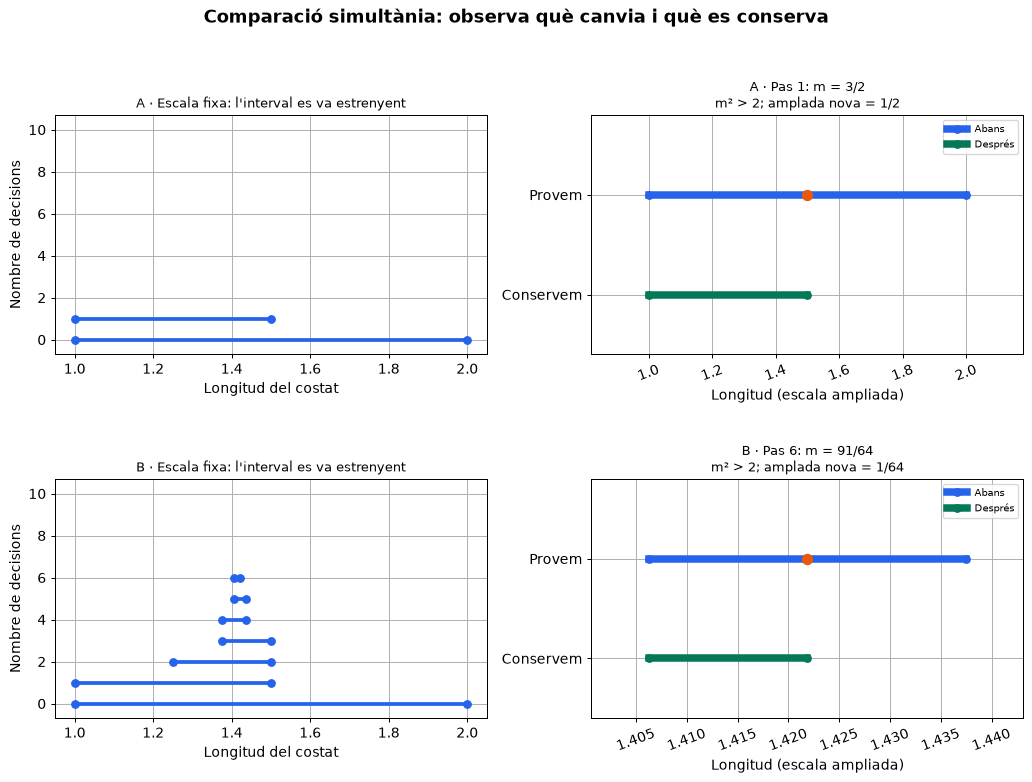

interactive(children=(Dropdown(description='Estat A:', options=(('Decisió 1', 0), ('Decisió 2', 1), ('Decisió …

In [12]:
compara_estats(*parella_comparacio)
panell_comparacio = controls_comparacio()


### Taller de Python · canvia una dada i explica l'efecte

Canvia l'àrea del quadrat de 2 a 3. Abans d'executar, calcula les dues primeres decisions. Després canvia el nombre de passos i explica què representa l'última amplada.

**Fes-ho en tres passos:** escriu una predicció, modifica les dades indicades i contrasta el resultat. Acaba amb una explicació matemàtica; executar la cel·la és només una part de la tasca.


In [13]:
area = Fraction(3)        # Prova també 2 o 5/2, escrit Fraction(5, 2).
passos = 6
a, b = Fraction(1), Fraction(2)  # Volem 1 < area < 4.
if not a*a < area < b*b:
    raise ValueError("Tria una àrea entre 1 i 4 per a aquest interval inicial.")
for k in range(1, passos+1):
    m = (a+b)/2
    if m*m == area:
        a = b = m
        print(f"Pas {k}: arrel racional exacta {m}.")
        break
    if m*m < area:
        a = m
    else:
        b = m
    print(f"Pas {k}: [{a}, {b}], amplada = {b-a}")
print("La comparació dels quadrats usa fraccions exactes.")


Pas 1: [3/2, 2], amplada = 1/2
Pas 2: [3/2, 7/4], amplada = 1/4
Pas 3: [13/8, 7/4], amplada = 1/8
Pas 4: [27/16, 7/4], amplada = 1/16
Pas 5: [55/32, 7/4], amplada = 1/32
Pas 6: [55/32, 111/64], amplada = 1/64
La comparació dels quadrats usa fraccions exactes.


### Atura't i comprova què has entès

Tria una resposta per pregunta i escriu una justificació abans de comprovar-la. Si t'equivoques, llegeix el retorn i torna al gràfic per localitzar el malentès.

**1. Després de 4 biseccions d'un interval d'amplada 1, quina amplada queda?**

- A. 1/4
- B. 1/16
- C. 0

**2. Si m² és menor que 2 i l'interval és positiu, quina meitat conservem?**

- A. [a,m]
- B. Qualsevol de les dues
- C. [m,b]

**3. Tots els punts mitjans són racionals. Què podem concloure sobre el límit?**

- A. Això no determina si el límit és racional
- B. És racional necessàriament
- C. És l'últim punt mig

Si no es mostren els controls, executa `mostra_feedback(1, 'B')`, canviant el número i la lletra. El retorn comprova l'opció; la justificació escrita s'ha de discutir a classe.


In [14]:
autoavaluacio = crea_autoavaluacio()


### Evidència final de l'aprenentatge

Completa aquestes frases amb un cas concret del taller:

1. **He canviat…**
2. **Esperava que… perquè…**
3. **El resultat ha estat…**
4. **Ara ho explico amb aquesta relació o propietat…**
5. **Un cas en què no puc generalitzar directament és…**

Torna a una pregunta que hagis corregit i explica què has canviat del teu raonament.


### Investiga i transfereix


1. Escriu la regla que permet trobar l'amplada després de $k$ passos. Quants passos calen
   perquè sigui menor que $0{,}001$? Justifica-ho amb una potència de 2.
2. Aplica dues decisions a la cerca de √3 dins [1, 2]. Quina comparació has de canviar?
3. Entre $7/5$ i $3/2$, construeix un racional nou amb el punt mig. Per què sempre en podràs construir un altre?
4. Explica la diferència entre «podem aproximar √2 amb racionals» i «√2 és racional».


### El teu raonament

Edita aquesta cel·la per deixar evidència del que has après.

- **Abans pensava que…**
- **He provat aquests valors…**
- **Al gràfic he observat…**
- **Ho justifico amb aquest càlcul o propietat…**
- **La meva conclusió i el seu límit són…**

No n'hi ha prou amb una captura: relaciona el dibuix, els nombres i l'explicació.


In [15]:
# Espai per al teu experiment: canvia l'índex i executa la cel·la.
# fotograma_laboratori(fotogrames_laboratori[0])
# Escriu aquí els càlculs del repte.


<details><summary>Comprovació: obre-la després d'intentar els reptes</summary>

L'amplada és $2^{-k}$; calen 10 passos perquè $2^{-10}<0{,}001$.
Per a √3: [3/2, 2] i després [3/2, 7/4]. El punt mig de 7/5 i 3/2 és 29/20,
estrictament entre els extrems. Una successió de racionals pot tenir un límit irracional;
la prova de la irracionalitat de √2 és una qüestió diferent de l'aproximació.

</details>

**Comprova el teu aprenentatge:** has interpretat els eixos i les unitats, justificat una predicció amb un càlcul i aplicat la idea a un cas nou? Una observació finita pot suggerir una propietat; una afirmació general necessita una justificació.


## 3. Per què falta un racional? · Ampliació formal
Suposem que $(p/q)^2=2$, amb $p,q$ enters primers entre si i $q\ne0$.
Aleshores $p^2=2q^2$, de manera que $p$ és parell: $p=2r$.
Substituint, $q^2=2r^2$, i $q$ també és parell. Això contradiu que $p/q$ sigui irreductible.

Per tant, **cap racional té quadrat igual a 2**. Els intervals construïts tenen
extrems racionals, però el punt que busquem no és racional. Més endavant justificarem
l'existència d'aquest punt en ℝ mitjançant la completesa.

## Activitats
1. Demostra que l'amplada després de $n$ biseccions és $2^{-n}$.
2. Troba un nombre de passos que garanteixi una amplada inferior a $10^{-6}$.
3. Explica per què executar un milió de passos no demostra la irracionalitat de l'arrel.
4. **Ampliació:** adapta la bisecció a $x^2=3$ i a $x^2=9$. Quina diferència observes?

<details><summary>Pistes i comprovació</summary>

Cada pas divideix l'amplada per 2; 20 passos són suficients perquè $2^{-20}<10^{-6}$.
A l'equació $x^2=9$ la solució positiva és racional. Cal tractar explícitament el cas
d'igualtat si generalitzes l'algorisme. Per als punts mitjans,
$a_n=q-(q-p)/2^n$.
</details>


**Navegació:** [Índex i guia](README.md) · [Següent](Càlcul_Nombre_pi.ipynb)
